In [16]:
# --- Collect air pollution data for Bengaluru ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params3 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}
import pandas as pd
import requests

try:
    r = requests.get(AQ_URL, params=params3, timeout=20)
    print("Status code:", r.status_code)
    aq = pd.DataFrame(r.json()["hourly"])
    aq["time"] = pd.to_datetime(aq["time"])
except Exception as e:
    print("Error occurred:", e)
    print("Using sample data instead")
    aq = pd.DataFrame({
        "time": pd.date_range("2026-08-01", periods=24, freq="h"),
        "pm2_5": [10.0]*24,
        "pm10": [20.0]*24,
        "nitrogen_dioxide": [15.0]*24,
        "ozone": [30.0]*24,
    })
    
from pathlib import Path
data = Path(".")  # current folder, or Path("data") for a subfolder
aq.to_csv(data / "air_quality.csv", index=False)
print("Saved to data / air_quality.csv",data)
print("Shape:", aq.shape)

aq.head()

Status code: 200
Saved to data / air_quality.csv .
Shape: (288, 5)


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2026-08-09 00:00:00,4.3,5.0,12.9,30.0
1,2026-08-09 01:00:00,3.3,3.8,9.8,32.0
2,2026-08-09 02:00:00,2.7,3.2,7.5,33.0
3,2026-08-09 03:00:00,2.5,3.2,6.2,34.0
4,2026-08-09 04:00:00,2.4,3.4,5.7,34.0


Average PM2.5: 7.0 ug/m3
Highest PM2.5: 16.0 ug/m3

Missing values in each column:
time                0
pm2_5               6
pm10                6
nitrogen_dioxide    6
ozone               6
dtype: int64


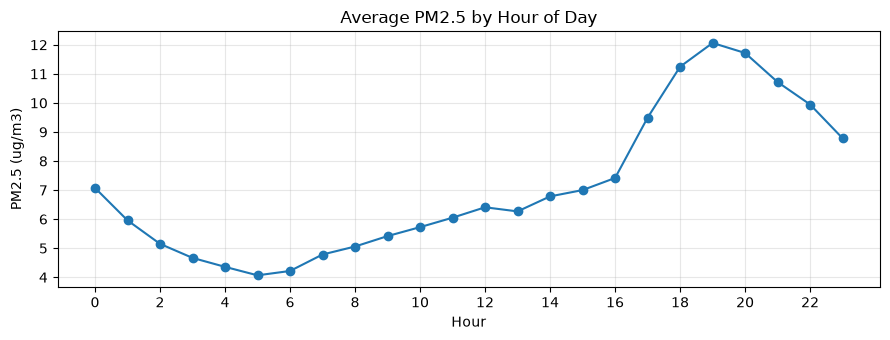

In [18]:
# --- Check what we collected ---

print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")
print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
#1.Collect the air quality data for Delhi (28.6139, 77.2090) and compare the average PM2.5 with Bengaluru's. Which city is more polluted?


params_delhi = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

r_delhi = requests.get(AQ_URL, params=params_delhi, timeout=20)
print("Status code:", r_delhi.status_code)

aq_delhi = pd.DataFrame(r_delhi.json()["hourly"])
aq_delhi["time"] = pd.to_datetime(aq_delhi["time"])

bengaluru_avg = round(aq["pm2_5"].mean(), 1)
delhi_avg = round(aq_delhi["pm2_5"].mean(), 1)

print("Bengaluru avg PM2.5:", bengaluru_avg)
print("Delhi avg PM2.5:", delhi_avg)
print("More polluted:", "Delhi" if delhi_avg > bengaluru_avg else "Bengaluru")

Status code: 200
Bengaluru avg PM2.5: 7.0
Delhi avg PM2.5: 61.1
More polluted: Delhi


In [23]:
#2. Increase past_days from 7 to 30. How many rows do you get now?


params3_30 = params3.copy()
params3_30["past_days"] = 30

r30 = requests.get(AQ_URL, params=params3_30, timeout=20)
aq_30 = pd.DataFrame(r30.json()["hourly"])
print("Rows:", aq_30.shape[0])

Rows: 840


In [24]:
#3. Add "sulphur_dioxide" and "carbon_monoxide" to the list of pollutants.


params3_more = params3.copy()
params3_more["hourly"] = "pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide"

r_more = requests.get(AQ_URL, params=params3_more, timeout=20)
aq_more = pd.DataFrame(r_more.json()["hourly"])
aq_more.head()

,time,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide
0,2026-08-09T00:00,4.3,5.0,12.9,30.0,3.9,205.0
1,2026-08-09T01:00,3.3,3.8,9.8,32.0,3.4,164.0
2,2026-08-09T02:00,2.7,3.2,7.5,33.0,3.0,138.0
3,2026-08-09T03:00,2.5,3.2,6.2,34.0,2.9,133.0
4,2026-08-09T04:00,2.4,3.4,5.7,34.0,2.8,144.0
